In [1]:
from __future__ import annotations

import os
import argparse
import json
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset

In [ ]:
@dataclass
class TrainConfig:
    dataset_path: str

    out_dir: str = "./models"
    run_name: str = "fno1d_lambda"

    batch_size: int = 16
    epochs: int = 300
    lr: float = 1e-3
    weight_decay: float = 1e-6

    width: int = 128
    modes: int = 32
    depth: int = 5
    hidden_proj: int = 128

    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    seed: int = 42

    # data
    in_channels: int = 5  # [lambda_in, mu1, mu2, mu3, zeta]


# ----------------------------
# Data
# ----------------------------
class LambdaDataset(Dataset):
    def __init__(self, data: Dict[str, np.ndarray], split: str) -> None:
        self.x = data["X_lambda"][data[split]]          # [Ns, Nz]
        self.y = data["Y_lambda"][data[split]]          # [Ns, Nz]
        self.mu = data["MU"][data[split]]               # [Ns, 3]
        self.zeta_grid = data["zeta_grid"]              # [Nz]

    def __len__(self) -> int:
        return self.x.shape[0]

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.x[idx]).float()          # [Nz]
        y = torch.from_numpy(self.y[idx]).float()          # [Nz]
        mu_raw = torch.from_numpy(self.mu[idx]).float()        # [3]

        # ---- normalize mu (mu = [Q, a, Z_scale])
        # log-scale Q and Z_scale to reduce dynamic range
        mu0 = torch.log10(mu_raw[0].clamp_min(1e-30))
        mu1 = mu_raw[1]
        mu2 = torch.log10(mu_raw[2].clamp_min(1e-30))
        mu = torch.stack([mu0, mu1, mu2], dim=0)


        grid = torch.from_numpy(self.zeta_grid).float()    # [Nz]

        # ---- scale zeta to [-1, 1] so the coordinate channel is O(1)
        grid_scaled = 2.0 * (grid - grid.min()) / (grid.max() - grid.min() + 1e-12) - 1.0

        # ---- normalize lambda curves to integrate to 1 (PDF)
        dz = (grid_scaled[-1] - grid_scaled[0]) / max(1, grid_scaled.numel() - 1)
        x = x / (x.sum() * dz + 1e-12)
        y = y / (y.sum() * dz + 1e-12)

        # features: [Nz, 5]
        features = torch.stack(
            [
                x,
                torch.full_like(x, mu[0]),
                torch.full_like(x, mu[1]),
                torch.full_like(x, mu[2]),
                grid_scaled,
            ],
            dim=-1,
        )
        return features, y


def load_npz(path: str) -> Dict[str, np.ndarray]:
    raw = np.load(path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}

# ----------------------------
# Helpers
# ----------------------------

def dz_from_grid(grid: torch.Tensor) -> torch.Tensor:
    # grid: [Nz]
    return (grid[-1] - grid[0]) / max(1, grid.numel() - 1)

def normalize_lambda_torch(lam: torch.Tensor, grid: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    # lam: [B,Nz], grid: [Nz]
    dz = dz_from_grid(grid)
    mass = torch.sum(lam, dim=-1, keepdim=True) * dz
    return lam / (mass + eps)

def moments_from_lambda_torch(lam: torch.Tensor, grid: torch.Tensor, eps: float = 1e-12):
    # lam: [B,Nz], grid: [Nz]
    dz = dz_from_grid(grid)

    


    lamn = normalize_lambda_torch(lam, grid, eps)

    mean = torch.sum(grid[None, :] * lamn, dim=-1) * dz                         # [B]
    var = torch.sum((grid[None, :] - mean[:, None])**2 * lamn, dim=-1) * dz     # [B]
    sig = torch.sqrt(torch.clamp(var, min=0.0))

    return mean, sig



# ----------------------------
# FNO model
# ----------------------------
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, modes: int) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes
        scale = 1.0 / max(1, in_channels * out_channels)
        self.weight_real = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes))
        self.weight_imag = nn.Parameter(scale * torch.randn(in_channels, out_channels, modes))

    def compl_weight(self) -> torch.Tensor:
        return torch.complex(self.weight_real, self.weight_imag)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, N]
        B, _, n = x.shape
        x_ft = torch.fft.rfft(x, dim=-1)
        n_modes = min(self.modes, x_ft.shape[-1])

        out_ft = torch.zeros(B, self.out_channels, x_ft.shape[-1], dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :n_modes] = torch.einsum(
            "bim,iom->bom",
            x_ft[:, :, :n_modes],
            self.compl_weight()[:, :, :n_modes],
        )
        x = torch.fft.irfft(out_ft, n=n, dim=-1)
        return x


class FNOBlock1d(nn.Module):
    def __init__(self, width: int, modes: int) -> None:
        super().__init__()
        self.spectral = SpectralConv1d(width, width, modes)
        self.local = nn.Conv1d(width, width, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.spectral(x) + self.local(x))


class FNO1d(nn.Module):
    def __init__(
        self,
        in_channels: int = 5,
        width: int = 64,
        modes: int = 16,
        depth: int = 4,
        hidden_proj: int = 128,
    ) -> None:
        super().__init__()
        self.lift = nn.Linear(in_channels, width)
        self.blocks = nn.ModuleList([FNOBlock1d(width, modes) for _ in range(depth)])
        self.proj1 = nn.Conv1d(width, hidden_proj, kernel_size=1)
        self.proj2 = nn.Conv1d(hidden_proj, 1, kernel_size=1)
        self.act = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, N, C]
        x_in = x[..., 0]          # [B, N] = lambda_in (already normalized)

        h = self.lift(x)          # [B, N, W]
        h = h.permute(0, 2, 1)    # [B, W, N]
        for block in self.blocks:
            h = block(h)
        h = self.act(self.proj1(h))
        h = self.proj2(h)
        delta = h[:, 0, :]        # [B, N]

        # residual prediction
        y = x_in + delta
        return y


# ----------------------------
# Metrics
# ----------------------------
def relative_l2(pred: torch.Tensor, target: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    num = torch.sum((pred - target) ** 2, dim=-1)
    den = torch.sum(target ** 2, dim=-1) + eps
    return torch.mean(torch.sqrt(num / den))


def line_density_mass(pred: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    # pred: [B, Nz], grid: [Nz]
    dz = (grid[-1] - grid[0]) / max(1, grid.numel() - 1)
    return torch.sum(pred, dim=-1) * dz


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    mse_sum = 0.0
    rel_sum = 0.0
    mass_err_sum = 0.0
    count = 0

    for features, target in loader:
        features = features.to(device)
        target = target.to(device)
        pred = model(features)

        mse = torch.mean((pred - target) ** 2)
        rel = relative_l2(pred, target)

        grid = features[0, :, -1]  # zeta grid from features (same for whole batch)
        mass_pred = line_density_mass(pred, grid)
        mass_true = line_density_mass(target, grid)
        mass_err = torch.mean(torch.abs(mass_pred - mass_true))

        b = target.size(0)
        mse_sum += mse.item() * b
        rel_sum += rel.item() * b
        mass_err_sum += mass_err.item() * b
        count += b

    return {
        "mse": mse_sum / max(1, count),
        "rel_l2": rel_sum / max(1, count),
        "mass_abs_err": mass_err_sum / max(1, count),
    }


# ----------------------------
# Train
# ----------------------------
def train(cfg: TrainConfig) -> None:
    Path(cfg.out_dir).mkdir(parents=True, exist_ok=True)
    
    torch.manual_seed(cfg.seed)
    np.random.seed(cfg.seed)

    data = load_npz(cfg.dataset_path)
    train_ds = LambdaDataset(data, "train")
    val_ds = LambdaDataset(data, "val")

    train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=cfg.batch_size, shuffle=False, num_workers=0)

    model = FNO1d(
        in_channels=cfg.in_channels,
        width=cfg.width,
        modes=cfg.modes,
        depth=cfg.depth,
        hidden_proj=cfg.hidden_proj,
    ).to(cfg.device)

    opt = torch.optim.Adam(
        model.parameters(),
        lr=cfg.lr, 
        weight_decay=cfg.weight_decay
        )
    
    scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=25, gamma=0.5)


    best_val = float("inf")
    best_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_best.pt")
    last_path = os.path.join(cfg.out_dir, f"{cfg.run_name}_last.pt")

    # save config once
    Path(os.path.join(cfg.out_dir, f"{cfg.run_name}_config.json")).write_text(
        json.dumps(asdict(cfg), indent=2)
    )

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        epoch_loss = 0.0
        n_seen = 0

        for features, target in train_loader:
            features = features.to(cfg.device)
            target = target.to(cfg.device)

            opt.zero_grad()
            pred = model(features)
            
            x_in = features[..., 0]  # [B,Nz]
            loss_fit = torch.mean(((pred - x_in) - (target - x_in))**2)

            grid = features[0, :, -1]  # scaled zeta in [-1,1]
            pred_n = normalize_lambda_torch(pred, grid)
            targ_n = normalize_lambda_torch(target, grid)
            m_pred, s_pred = moments_from_lambda_torch(pred_n, grid)
            m_true, s_true = moments_from_lambda_torch(targ_n, grid)
            loss_mom = torch.mean((m_pred - m_true) ** 2) + torch.mean((s_pred - s_true) ** 2)

            loss = loss_fit + 0.1 * loss_mom
            
            
            loss.backward()
            opt.step()

            b = features.shape[0]
            epoch_loss += loss.item() * b
            n_seen += b

        scheduler.step()
        train_loss = epoch_loss / max(1, n_seen)
        val_metrics = evaluate(model, val_loader, cfg.device)

        if val_metrics["rel_l2"] < best_val:
            best_val = val_metrics["rel_l2"]
            torch.save(
                {
                    "state_dict": model.state_dict(),
                    "cfg": asdict(cfg),
                    "epoch": epoch,
                    "val_metrics": val_metrics,
                },
                best_path,
            )

        if epoch == 1 or epoch % 10 == 0:
            print(
                f"epoch={epoch:03d} train_loss={train_loss:.3e} "
                f"| val_mse={val_metrics['mse']:.3e} "
                f"val_rel_l2={val_metrics['rel_l2']:.3e} "
                f"val_mass_abs_err={val_metrics['mass_abs_err']:.3e}"
            )

    # save last
    torch.save(
        {
            "state_dict": model.state_dict(),
            "cfg": asdict(cfg),
            "epoch": cfg.epochs,
        },
        last_path,
    )
    print("[OK] saved:", best_path)
    print("[OK] saved:", last_path)

In [3]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Train a minimal 1D FNO on Xsuite density data.")
    parser.add_argument("--dataset-path", type=str, default="./data/neural/xsuite_neural_dataset.npz")
    parser.add_argument("--batch-size", type=int, default=16)
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight-decay", type=float, default=1e-6)
    parser.add_argument("--width", type=int, default=64)
    parser.add_argument("--modes", type=int, default=16)
    parser.add_argument("--depth", type=int, default=4)
    parser.add_argument("--hidden-proj", type=int, default=128)
    parser.add_argument("--device", type=str, default="cuda" if torch.cuda.is_available() else "cpu")
    parser.add_argument("--seed", type=int, default=42)
    parser.add_argument("--save-model", type=str, default="")
    return parser.parse_args()



In [4]:
path = "/pbs/home/s/smartinez/ML4CollEffects/data/neural/neural_xsuite_dataset_2026-05-07T09:46:05.npz"   # or "/data/neural/xsuite_neural_dataset.npz"
data = load_npz(path)   # uses the notebook's helper; or: data = dict(np.load(path, allow_pickle=True))

print("keys:", sorted(data.keys()))
for k in sorted(data.keys()):
    v = data[k]
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: type={type(v)}")

keys: ['MU', 'X_cloud', 'X_lambda', 'Y_cloud', 'Y_lambda', 'centroid_in', 'centroid_out', 'cov_in', 'cov_out', 'family_id', 'test', 'train', 'val', 'zeta_grid']
  MU: shape=(1024, 3), dtype=float32
  X_cloud: shape=(1024, 1024, 6), dtype=float32
  X_lambda: shape=(1024, 512), dtype=float32
  Y_cloud: shape=(1024, 1024, 6), dtype=float32
  Y_lambda: shape=(1024, 512), dtype=float32
  centroid_in: shape=(1024, 6), dtype=float32
  centroid_out: shape=(1024, 6), dtype=float32
  cov_in: shape=(1024, 6, 6), dtype=float32
  cov_out: shape=(1024, 6, 6), dtype=float32
  family_id: shape=(1024,), dtype=<U19
  test: shape=(103,), dtype=int64
  train: shape=(819,), dtype=int64
  val: shape=(102,), dtype=int64
  zeta_grid: shape=(512,), dtype=float32


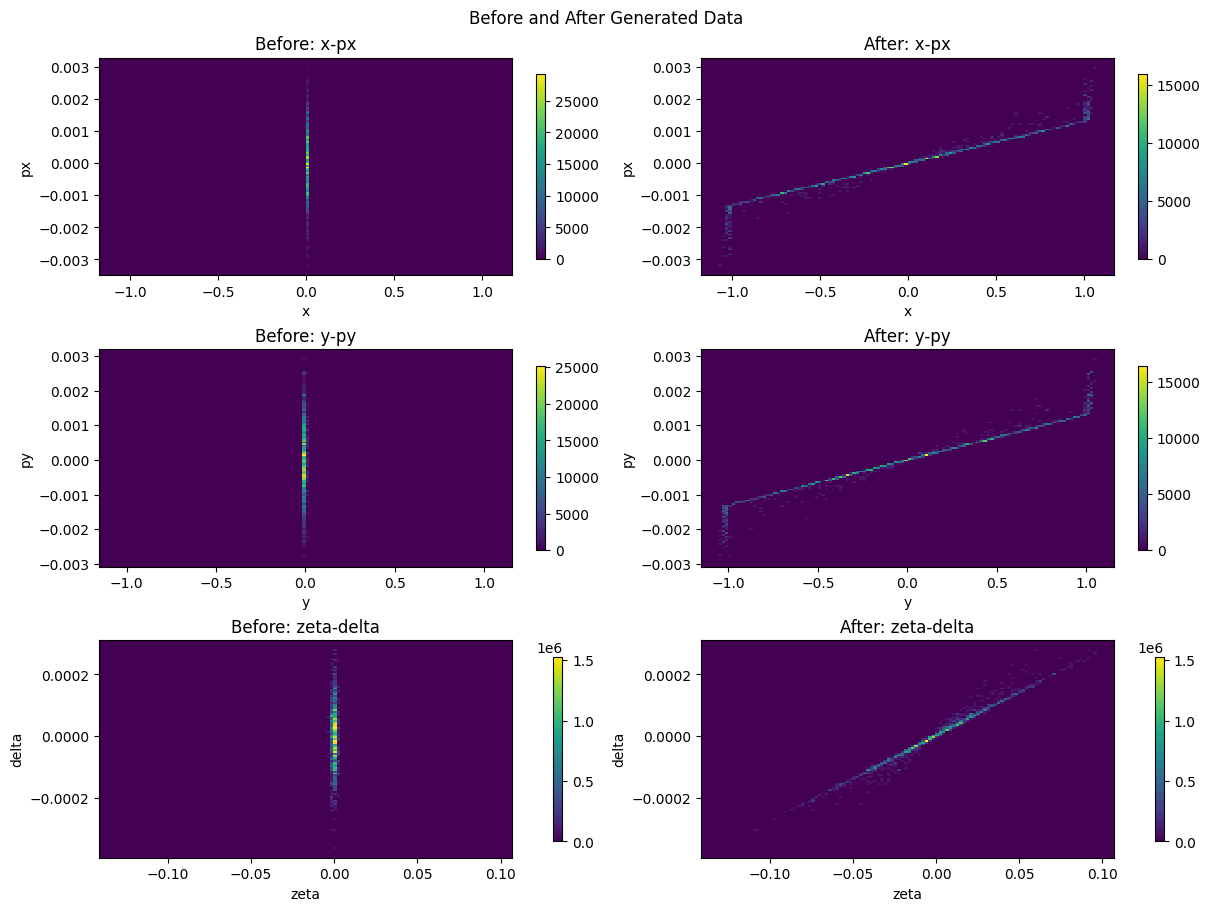

In [5]:
import matplotlib.pyplot as plt

def plot_example_distributions(i: int = 0, bins: int = 100, figsize: tuple = (12, 9),cmap = "viridis", title: str = "Before and After Generated Data") -> None:
    """
    Plot before/after 2D marginal histograms for the i-th example:
      - Row 1: x/px before (left) and after (right)
      - Row 2: y/py before (left) and after (right)
      - Row 3: zeta/delta before (left) and after (right)

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_before[:, [i, j]], z_after[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_before[:, i], z_before[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_after[:, i], z_after[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()


    
idx_random = np.random.randint(512)
plot_example_distributions(i=idx_random, bins=120)

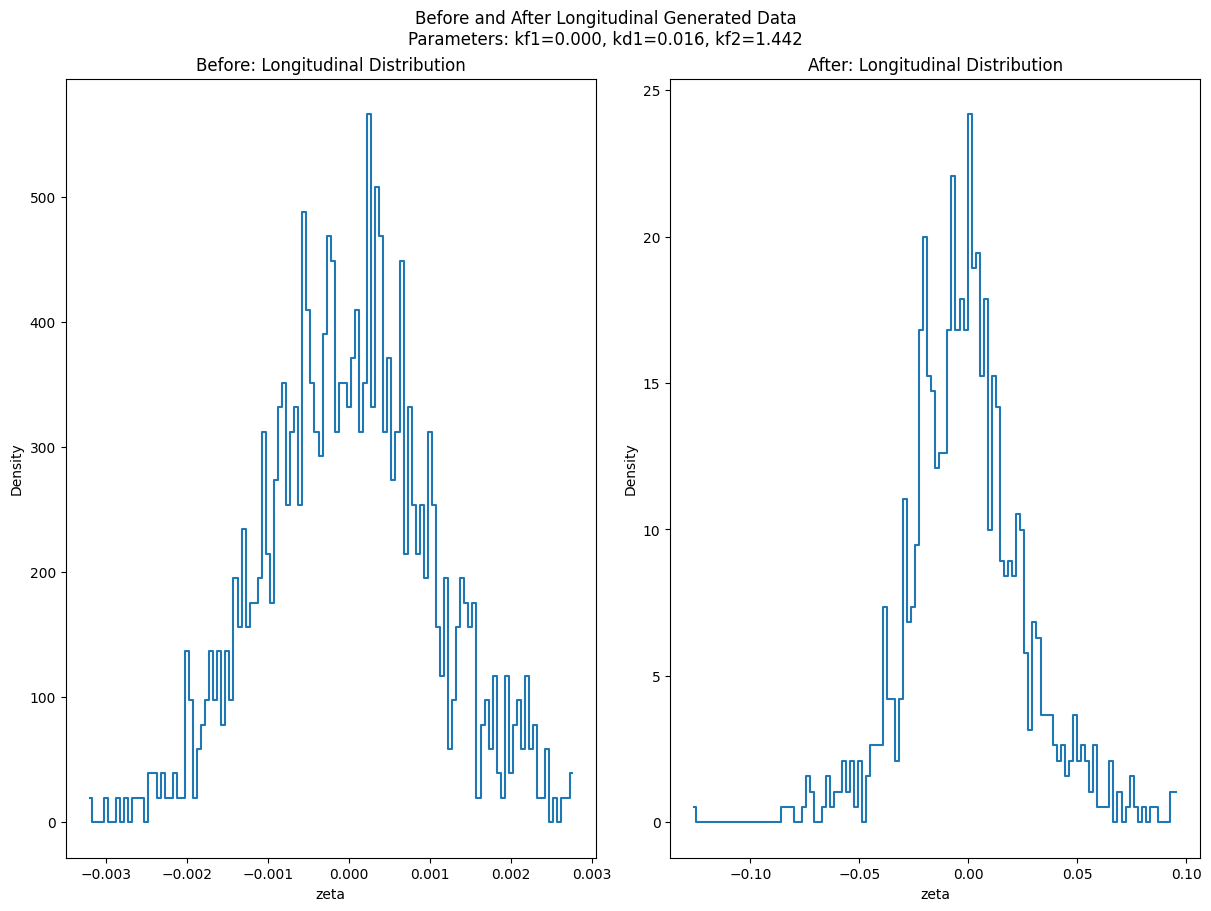

In [6]:
def plot_longitudinal_distribution(i: int = 0, bins: int = 100, figsize: tuple = (12, 9), title: str = "Before and After Longitudinal Generated Data") -> None: 
    """
    Plot before/after histograms for the zeta distribution of the i-th example.

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]
    MU = None
    if "MU" in data:
        MU = data["MU"]  # shape (n_samples, 3)
        if not (0 <= i < MU.shape[0]):
            raise IndexError(f"i out of range for MU (0 <= i < {MU.shape[0]})")
        mu_i = MU[i]
        title += f"\nParameters: kf1={mu_i[0]:.3f}, kd1={mu_i[1]:.3f}, kf2={mu_i[2]:.3f}"

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    for idx, (z, ax, label) in enumerate(zip([z_before, z_after], axes, ["Before", "After"])):
        hist, edges = np.histogram(z[:, 2], bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, hist, drawstyle="steps-mid")
        ax.set_title(f"{label}: Longitudinal Distribution")
        ax.set_xlabel("zeta")
        ax.set_ylabel("Density")

    fig.suptitle(title)
    plt.show()

idx_random = np.random.randint(512)
plot_longitudinal_distribution(i=idx_random, bins=120)

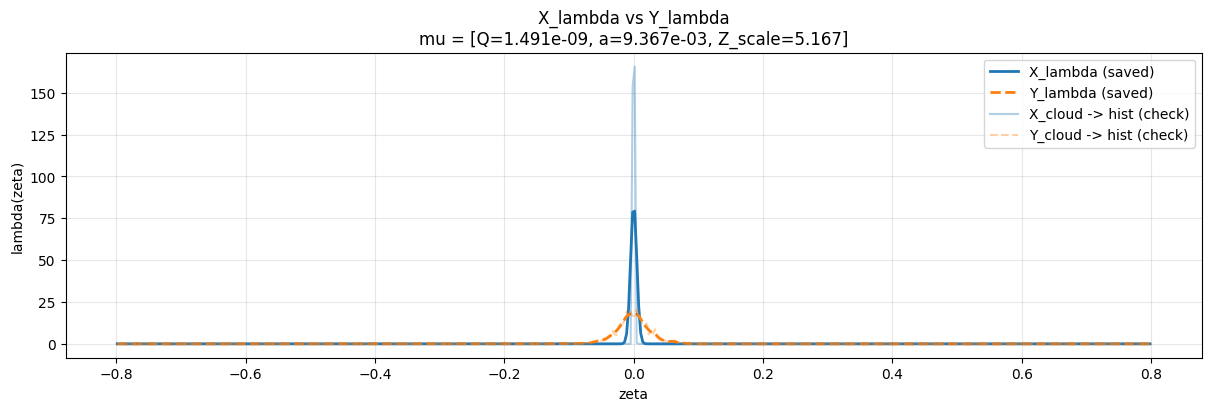

In [7]:


def plot_lambda_distribution(
    data: dict,
    i: int = 0,
    figsize: tuple = (12, 4),
    title: str = "X_lambda vs Y_lambda",
    show_cloud_overlay: bool = True,
    cloud_bins: int = 120,
) -> None:
    """
    Plot before/after *line density* lambda(zeta) for the i-th example.

    Expects data dict with keys:
      - "zeta_grid" [Nz]
      - "X_lambda"  [Ns, Nz]
      - "Y_lambda"  [Ns, Nz]
    Optionally overlays a histogram built from X_cloud/Y_cloud for sanity check.
    """
    required = ("zeta_grid", "X_lambda", "Y_lambda")
    for k in required:
        if k not in data:
            raise RuntimeError(f"data must contain key {k!r}")

    zeta = np.asarray(data["zeta_grid"], dtype=np.float64)
    Xl = np.asarray(data["X_lambda"], dtype=np.float64)
    Yl = np.asarray(data["Y_lambda"], dtype=np.float64)

    n_samples = Xl.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    # annotate mu if present
    full_title = title
    if "MU" in data:
        mu_i = np.asarray(data["MU"][i], dtype=np.float64)
        full_title += f"\nmu = [Q={mu_i[0]:.3e}, a={mu_i[1]:.3e}, Z_scale={mu_i[2]:.3f}]"

    fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)

    ax.plot(zeta, Xl[i], label="X_lambda (saved)", lw=2)
    ax.plot(zeta, Yl[i], label="Y_lambda (saved)", lw=2, ls="--")

    # Optional overlay: histogram from clouds using the same zeta grid binning
    if show_cloud_overlay and ("X_cloud" in data) and ("Y_cloud" in data):
        Xc = np.asarray(data["X_cloud"][i], dtype=np.float64)
        Yc = np.asarray(data["Y_cloud"][i], dtype=np.float64)

        # Build edges from zeta_grid centers (assumes uniform spacing)
        dz = float(zeta[1] - zeta[0])
        edges = np.concatenate([[zeta[0] - 0.5 * dz], zeta + 0.5 * dz])

        hx, _ = np.histogram(Xc[:, 2], bins=edges, density=False)
        hy, _ = np.histogram(Yc[:, 2], bins=edges, density=False)

        # normalize like your generator: integral = 1
        hx = hx.astype(np.float64) / (hx.sum() * dz + 1e-12)
        hy = hy.astype(np.float64) / (hy.sum() * dz + 1e-12)

        ax.plot(zeta, hx, label="X_cloud -> hist (check)", color="C0", alpha=0.35)
        ax.plot(zeta, hy, label="Y_cloud -> hist (check)", color="C1", alpha=0.35, ls="--")

    ax.set_title(full_title)
    ax.set_xlabel("zeta")
    ax.set_ylabel("lambda(zeta)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.show()


idx_random = np.random.randint(data["X_lambda"].shape[0])
plot_lambda_distribution(data, i=idx_random, show_cloud_overlay=True)

dz: 0.0031249523162841797
frac_outside X,Y: 0.0 0.0
mean|X_saved-X_re|: 0.6312298212424288
mean|Y_saved-Y_re|: 0.11369416776070809


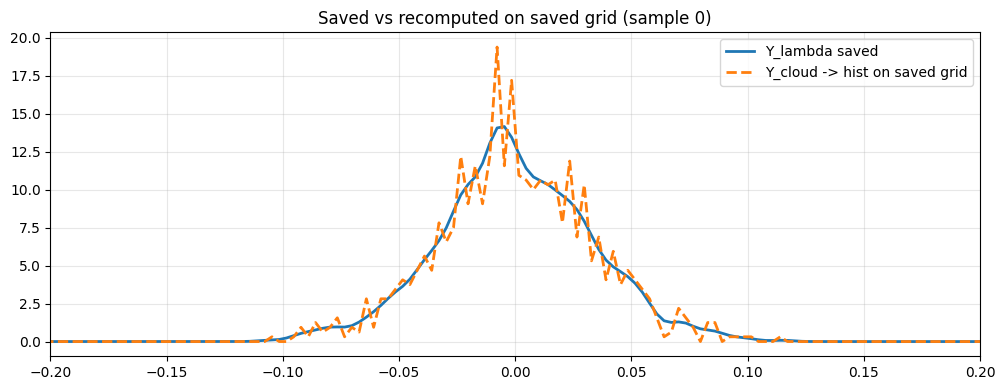

In [8]:
def edges_from_centers(centers: np.ndarray) -> np.ndarray:
    centers = np.asarray(centers, dtype=np.float64)
    dz = float(centers[1] - centers[0])
    return np.concatenate([[centers[0] - 0.5*dz], centers + 0.5*dz])

def lambda_hist_on_saved_grid(zeta_samples: np.ndarray, centers: np.ndarray, eps: float = 1e-12):
    edges = edges_from_centers(centers)
    dz = float(edges[1] - edges[0])
    h, _ = np.histogram(zeta_samples, bins=edges, density=False)
    lam = h.astype(np.float64)
    lam = lam / (lam.sum() * dz + eps)
    frac_out = float(np.mean((zeta_samples < edges[0]) | (zeta_samples > edges[-1])))
    return lam, frac_out, dz

i = 0
centers = data["zeta_grid"].astype(np.float64)

X_saved = data["X_lambda"][i].astype(np.float64)
Y_saved = data["Y_lambda"][i].astype(np.float64)

X_re, fx, dz = lambda_hist_on_saved_grid(data["X_cloud"][i][:,2].astype(np.float64), centers)
Y_re, fy, dz = lambda_hist_on_saved_grid(data["Y_cloud"][i][:,2].astype(np.float64), centers)

print("dz:", dz)
print("frac_outside X,Y:", fx, fy)
print("mean|X_saved-X_re|:", float(np.mean(np.abs(X_saved - X_re))))
print("mean|Y_saved-Y_re|:", float(np.mean(np.abs(Y_saved - Y_re))))

plt.figure(figsize=(10,4))
plt.plot(centers, Y_saved, label="Y_lambda saved", lw=2)
plt.plot(centers, Y_re, "--", label="Y_cloud -> hist on saved grid", lw=2)
plt.grid(alpha=0.3); plt.legend()
plt.title(f"Saved vs recomputed on saved grid (sample {i})")
plt.tight_layout()
plt.xlim(-0.2,0.2)
plt.show()

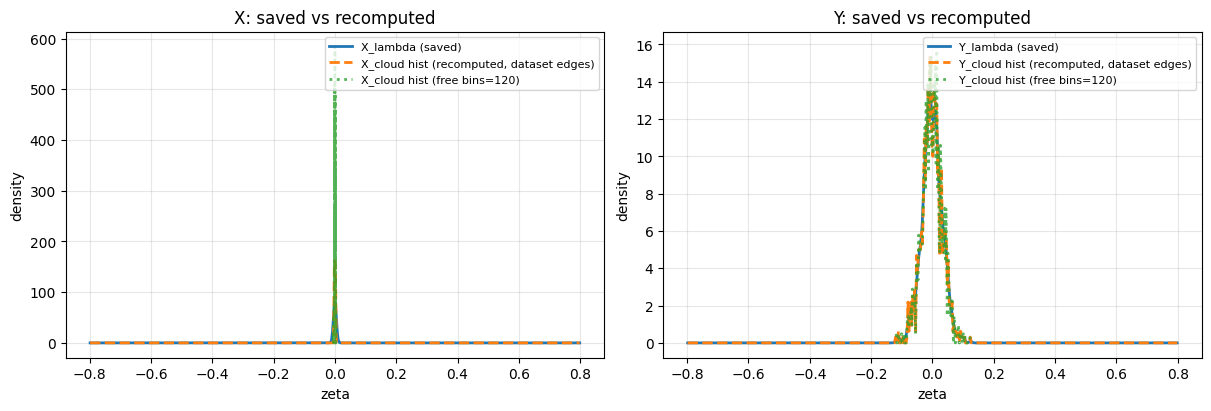

dz from zeta_grid: 0.0031249523162841797
Integral saved X: 0.9999847463776341 recomputed X: 0.9999999999996874
Integral saved Y: 0.9999847531173954 recomputed Y: 0.9999999999996874
mean|Y_saved - Y_recomputed|: 0.09975575420440258
max |Y_saved - Y_recomputed|: 3.365694044930563
fraction of Y_cloud zeta outside [edges[0], edges[-1]]: 0.0


In [9]:


def plot_lambda_sanity(data: dict, i: int = 0, bins_cloud: int = 120, figsize=(12,4)):
    """
    Compare:
      - saved X_lambda/Y_lambda
      - recomputed histograms from X_cloud/Y_cloud using edges derived from zeta_grid
      - plus your 'looks fine' histogram with arbitrary bins (for visual reference)
    """
    zeta = np.asarray(data["zeta_grid"], dtype=np.float64)         # centers [Nz]
    Xl = np.asarray(data["X_lambda"][i], dtype=np.float64)
    Yl = np.asarray(data["Y_lambda"][i], dtype=np.float64)
    Xc = np.asarray(data["X_cloud"][i], dtype=np.float64)
    Yc = np.asarray(data["Y_cloud"][i], dtype=np.float64)

    # Build edges that correspond to zeta_grid centers (assumes uniform spacing)
    dz = float(zeta[1] - zeta[0])
    edges = np.concatenate([[zeta[0] - 0.5 * dz], zeta + 0.5 * dz])  # length Nz+1

    # Recompute using EXACT dataset binning
    hx, _ = np.histogram(Xc[:, 2], bins=edges, density=False)
    hy, _ = np.histogram(Yc[:, 2], bins=edges, density=False)
    hx = hx.astype(np.float64) / (hx.sum() * dz + 1e-12)
    hy = hy.astype(np.float64) / (hy.sum() * dz + 1e-12)

    # Your "looks fine" histogram (arbitrary bins)
    hx_free, ex_free = np.histogram(Xc[:, 2], bins=bins_cloud, density=True)
    hy_free, ey_free = np.histogram(Yc[:, 2], bins=bins_cloud, density=True)
    cx_free = 0.5*(ex_free[:-1] + ex_free[1:])
    cy_free = 0.5*(ey_free[:-1] + ey_free[1:])

    fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    # Left: X comparison
    ax[0].plot(zeta, Xl, label="X_lambda (saved)", lw=2)
    ax[0].plot(zeta, hx, "--", label="X_cloud hist (recomputed, dataset edges)", lw=2)
    ax[0].plot(cx_free, hx_free, ":", label=f"X_cloud hist (free bins={bins_cloud})", lw=2, alpha=0.8)
    ax[0].set_title("X: saved vs recomputed")
    ax[0].set_xlabel("zeta"); ax[0].set_ylabel("density")
    ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)

    # Right: Y comparison
    ax[1].plot(zeta, Yl, label="Y_lambda (saved)", lw=2)
    ax[1].plot(zeta, hy, "--", label="Y_cloud hist (recomputed, dataset edges)", lw=2)
    ax[1].plot(cy_free, hy_free, ":", label=f"Y_cloud hist (free bins={bins_cloud})", lw=2, alpha=0.8)
    ax[1].set_title("Y: saved vs recomputed")
    ax[1].set_xlabel("zeta"); ax[1].set_ylabel("density")
    ax[1].grid(alpha=0.3); ax[1].legend(fontsize=8)

    plt.show()

    # Numeric diagnostics
    print("dz from zeta_grid:", dz)
    print("Integral saved X:", float(Xl.sum()*dz), "recomputed X:", float(hx.sum()*dz))
    print("Integral saved Y:", float(Yl.sum()*dz), "recomputed Y:", float(hy.sum()*dz))
    print("mean|Y_saved - Y_recomputed|:", float(np.mean(np.abs(Yl - hy))))
    print("max |Y_saved - Y_recomputed|:", float(np.max(np.abs(Yl - hy))))
    print("fraction of Y_cloud zeta outside [edges[0], edges[-1]]:",
          float(np.mean((Yc[:,2] < edges[0]) | (Yc[:,2] > edges[-1]))))



idx_random = np.random.randint(data["X_lambda"].shape[0])
plot_lambda_sanity(data, i=idx_random)

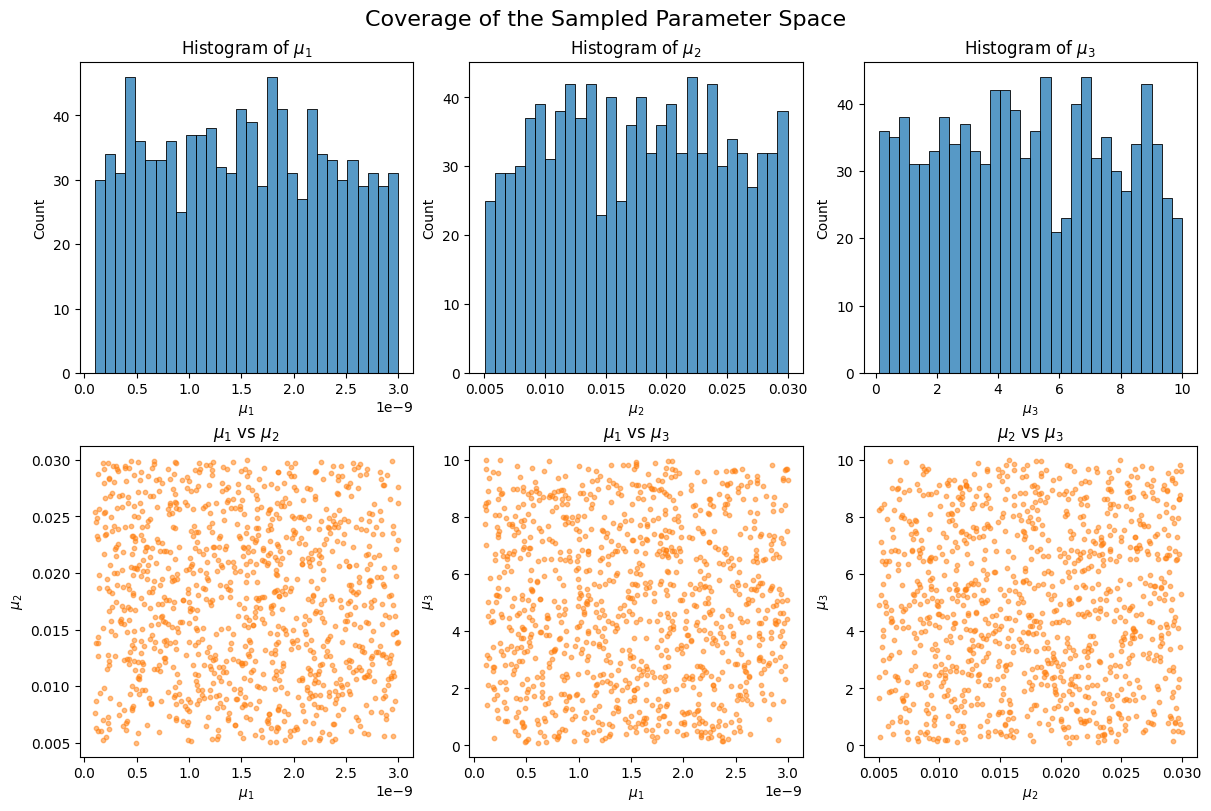

In [10]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

def plot_parameter_space(mu: np.ndarray, figsize: tuple = (12, 8)) -> None:
    """
    Visualize the coverage of the sampled parameter space.
    
    Parameters:
        mu (np.ndarray): Array of shape (n_samples, 3) containing the parameter vectors (kf1, kd1, kf2).
        figsize (tuple): Size of the figure.
    """
    if mu.shape[1] != 3:
        raise ValueError("mu must have shape (n_samples, 3)")

    labels = [r"$\mu_{1}$", r"$\mu_{2}$", r"$\mu_{3}$"]
    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)

    # Plot 1D histograms
    for i in range(3):
        sns.histplot(mu[:, i], kde=False, bins=30, ax=axes[0, i], color="C0")
        axes[0, i].set_xlabel(labels[i])
        axes[0, i].set_ylabel("Count")
        axes[0, i].set_title(f"Histogram of {labels[i]}")

    # Plot pairwise scatter plots
    pairs = [(0, 1), (0, 2), (1, 2)]
    for ax, (i, j) in zip(axes[1], pairs):
        ax.scatter(mu[:, i], mu[:, j], alpha=0.5, s=10, color="C1")
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        ax.set_title(f"{labels[i]} vs {labels[j]}")

    fig.suptitle("Coverage of the Sampled Parameter Space", fontsize=16)
    plt.show()

# Assuming `data["MU"]` contains the parameter vectors
plot_parameter_space(data["MU"])

In [11]:
args = argparse.Namespace(
    dataset_path="/pbs/home/s/smartinez/ML4CollEffects/data/neural/neural_xsuite_dataset_2026-05-06T09:07:30.npz",
    batch_size=16,
    epochs=300,
    lr=1e-3,
    weight_decay=1e-6,
    width=64,
    modes=16,
    depth=4,
    hidden_proj=128,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed=42,
    save_model="/data/neural/fno1d_model.pth",
)

In [12]:
cfg = TrainConfig(
        dataset_path=args.dataset_path,
        batch_size=args.batch_size,
        epochs=args.epochs,
        lr=args.lr,
        weight_decay=args.weight_decay,
        width=args.width,
        modes=args.modes,
        depth=args.depth,
        hidden_proj=args.hidden_proj,
        device=args.device,
        seed=args.seed,
    )
model = train(cfg)





epoch=001 train_loss=4.788e-01 | val_mse=3.522e-01 val_rel_l2=7.737e-01 val_mass_abs_err=4.847e-04


KeyboardInterrupt: 

In [ ]:
def plot_density_truth_vs_pred(sample_idx: int = 0, figsize: tuple = (12, 5)):
    """
    Plot 1D line density: truth vs prediction and the error (prediction - truth).
    Requires `data` dict and trained `model` in the notebook.
    """
    if "Y_lambda" not in data or "zeta_grid" not in data or "MU" not in data or "X_lambda" not in data:
        raise RuntimeError("data must contain 'X_lambda', 'Y_lambda', 'MU', and 'zeta_grid'")

    n_samples = data["Y_lambda"].shape[0]
    if not (0 <= sample_idx < n_samples):
        raise IndexError(f"sample_idx out of range (0 <= idx < {n_samples})")

    zeta = data["zeta_grid"].astype(np.float32)         # [Nz]
    y_true = data["Y_lambda"][sample_idx].astype(np.float32)
    x_in = data["X_lambda"][sample_idx].astype(np.float32)
    mu = data["MU"][sample_idx].astype(np.float32)

    # build features [Nz,5] like LambdaDataset and add batch dim
    features_np = np.stack(
        [
            x_in,
            np.full_like(x_in, mu[0]),
            np.full_like(x_in, mu[1]),
            np.full_like(x_in, mu[2]),
            zeta,
        ],
        axis=-1,
    )  # [Nz,5]

    # detect device from model
    device = next(model.parameters()).device if any(p.numel() for p in model.parameters()) else torch.device("cpu")

    model.eval()
    with torch.no_grad():
        feat_t = torch.from_numpy(features_np).unsqueeze(0).to(device).float()  # [1, Nz, 5]
        pred_t = model(feat_t)  # [1, Nz]
        y_pred = pred_t.squeeze(0).cpu().numpy()

    # metrics
    eps = 1e-12
    
    rel_l2 = np.sqrt(np.sum((y_pred - y_true) ** 2) / (np.sum(y_true ** 2) + eps))
    dz = (zeta[-1] - zeta[0]) / max(1, zeta.size - 1)
    mass_true = float(np.sum(y_true) * dz)
    mass_pred = float(np.sum(y_pred) * dz)
    mass_abs_err = float(abs(mass_pred - mass_true))
    abs_err = np.abs(y_pred - y_true)
    rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
    max_abs_err = float(abs_err.max())

    # plotting
    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    ax = axes[0]
    ax.plot(zeta, y_true, label="truth", lw=2)
    ax.plot(zeta, y_pred, label="pred", lw=1)
    ax.set_xlabel("zeta")
    ax.set_ylabel("density")
    ax.set_title(
        f"Sample {sample_idx} — line density\nrel_l2={rel_l2:.3e}, mass_err={mass_abs_err:.3e}"
    )
    ax.legend()

    ax2 = axes[1]
    ax2.plot(zeta,np.abs(y_pred - y_true), color="C3", lw=1)
    ax2.axhline(0.0, color="gray", lw=0.8, linestyle="--")
    ax2.set_xlabel("zeta")
    ax2.set_ylabel("(prediction - truth)")
    ax2.set_title(f"Error (pred - truth)\nRMSE={rmse:.3e}, max_abs={max_abs_err:.3e}")

    plt.show()





In [ ]:
def load_model_from_ckpt(ckpt_path: str, device: str = "cpu") -> FNO1d:
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg_dict = ckpt.get("cfg", {})  # might be missing if you saved differently

    model = FNO1d(
        in_channels=cfg_dict.get("in_channels", 5),
        width=cfg_dict.get("width", 128),
        modes=cfg_dict.get("modes", 32),
        depth=cfg_dict.get("depth", 5),
        hidden_proj=cfg_dict.get("hidden_proj", 128),
    ).to(device)

    state_dict = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [ ]:
model = load_model_from_ckpt("./models/fno1d_lambda_best.pt", device=cfg.device)
print(model)

FNO1d(
  (lift): Linear(in_features=5, out_features=64, bias=True)
  (blocks): ModuleList(
    (0-3): 4 x FNOBlock1d(
      (spectral): SpectralConv1d()
      (local): Conv1d(64, 64, kernel_size=(1,), stride=(1,))
      (act): GELU(approximate='none')
    )
  )
  (proj1): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  (proj2): Conv1d(128, 1, kernel_size=(1,), stride=(1,))
  (act): GELU(approximate='none')
)


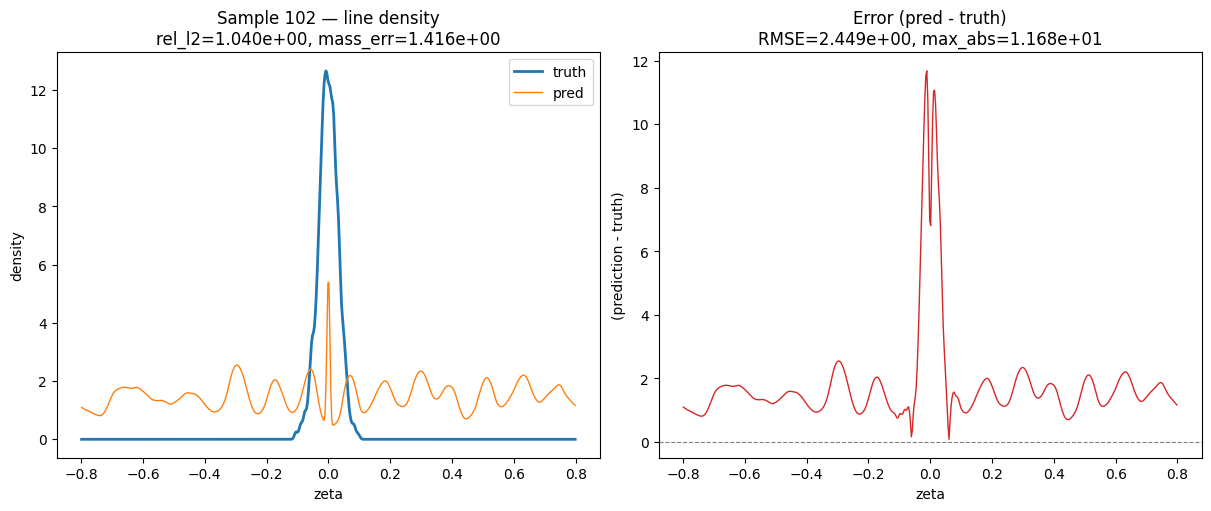

In [ ]:
idx_random = np.random.randint(0, data["Y_lambda"].shape[0])

plot_density_truth_vs_pred(sample_idx=idx_random)